In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

## 1) Chargement et nettoyage des données

In [2]:
df = pd.read_csv('./dataset/heart.csv')

df = pd.read_csv('/home/herilanja/Downloads/_DATA/heart.csv')

print("=" * 55)
print("APERÇU DU DATASET")
print("=" * 55)
print(f"  Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Variables       : {list(df.columns)}")
df.head(8)

APERÇU DU DATASET
  Dimensions      : 303 lignes × 14 colonnes
  Variables       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1


In [3]:
# Informations générales
print("=== Types et valeurs non-nulles ===")
df.info()

=== Types et valeurs non-nulles ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
print("=== Statistiques descriptives ===")
df.describe().round(2).transpose()


=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.37,9.08,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.97,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.62,17.54,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.26,51.83,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.65,22.91,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [6]:
# ─── Nettoyage ────────────────────────────────────
print("=" * 55)
print("RAPPORT DE NETTOYAGE")
print("=" * 55)

# 1. Valeurs manquantes
na_count = df.isnull().sum()
print(f"\n1. Valeurs manquantes : {na_count.sum()} au total")
if na_count.sum() > 0:
    print(na_count[na_count > 0])

# 2. Doublons
dup = df.duplicated().sum()
print(f"\n2. Doublons : {dup}")
if dup > 0:
    df = df.drop_duplicates()
    print(f"   → {dup} ligne(s) supprimée(s). Nouveau shape : {df.shape}")

# 3. Valeurs aberrantes — cholestérol à 0
zero_chol = (df['chol'] == 0).sum()
print(f"\n3. Cholestérol = 0 : {zero_chol} cas")
if zero_chol > 0:
    df.loc[df['chol'] == 0, 'chol'] = df['chol'].median()
    print(f"   → Remplacés par la médiane : {df['chol'].median():.1f}")

# 4. Valeurs aberrantes — trestbps à 0
zero_bp = (df['trestbps'] == 0).sum()
print(f"\n4. Pression artérielle = 0 : {zero_bp} cas")
if zero_bp > 0:
    df.loc[df['trestbps'] == 0, 'trestbps'] = df['trestbps'].median()

# 5. Distribution de la cible
print(f"\n5. Distribution de la cible :")
vc = df['target'].value_counts()
for cls, cnt in vc.items():
    label = "Maladie cardiaque" if cls == 1 else "Sain"
    print(f"   Classe {cls} ({label}) : {cnt} ({cnt/len(df)*100:.1f}%)")

print(f"\nDataset propre : {df.shape[0]} lignes × {df.shape[1]} colonnes")


RAPPORT DE NETTOYAGE

1. Valeurs manquantes : 0 au total

2. Doublons : 1
   → 1 ligne(s) supprimée(s). Nouveau shape : (302, 14)

3. Cholestérol = 0 : 0 cas

4. Pression artérielle = 0 : 0 cas

5. Distribution de la cible :
   Classe 1 (Maladie cardiaque) : 164 (54.3%)
   Classe 0 (Sain) : 138 (45.7%)

Dataset propre : 302 lignes × 14 colonnes


## 2) Analyse exploratoire

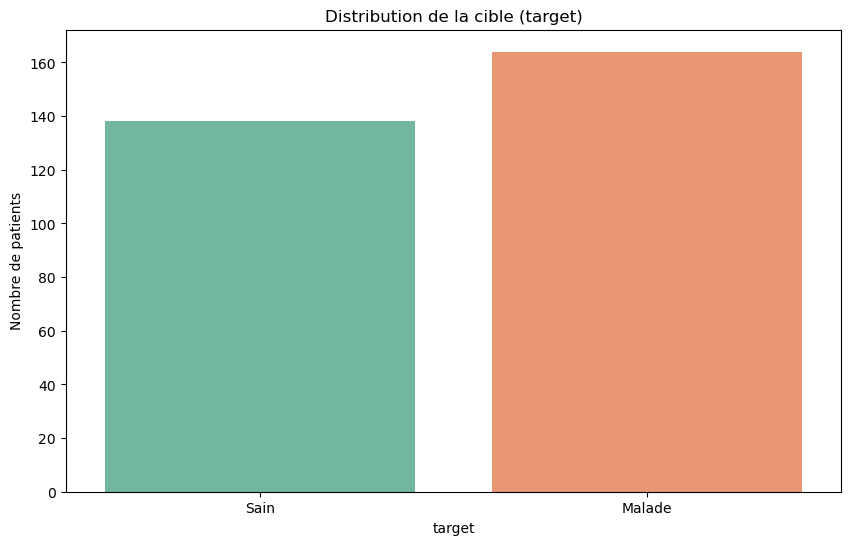

In [34]:
# ─── Visualisations ───────────────────────────────
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution de la cible (target)')
plt.xticks([0, 1], ['Sain', 'Malade'])
plt.ylabel('Nombre de patients')
plt.savefig('./images/EDA/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


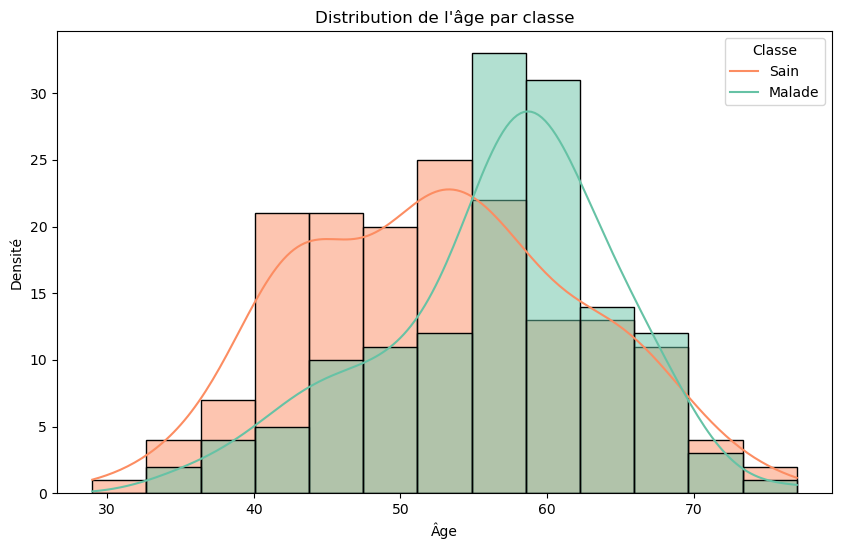

In [35]:
# ── Distribution âge par classe ──
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set2')
plt.title('Distribution de l\'âge par classe')
plt.xlabel('Âge')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

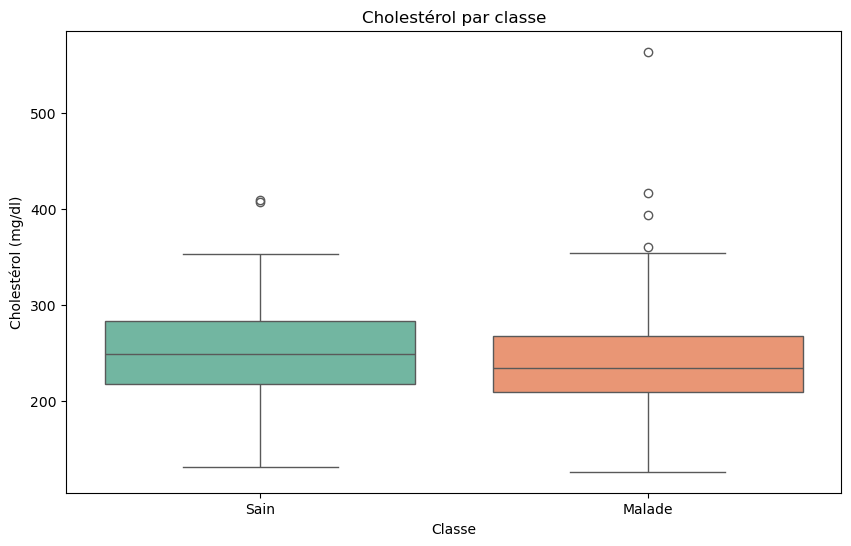

In [36]:
# ── Cholestérol par classe ──
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Cholestérol par classe')
plt.xlabel('Classe')
plt.ylabel('Cholestérol (mg/dl)')
plt.xticks([0, 1], ['Sain', 'Malade'])
plt.savefig('./images/EDA/cholesterol_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

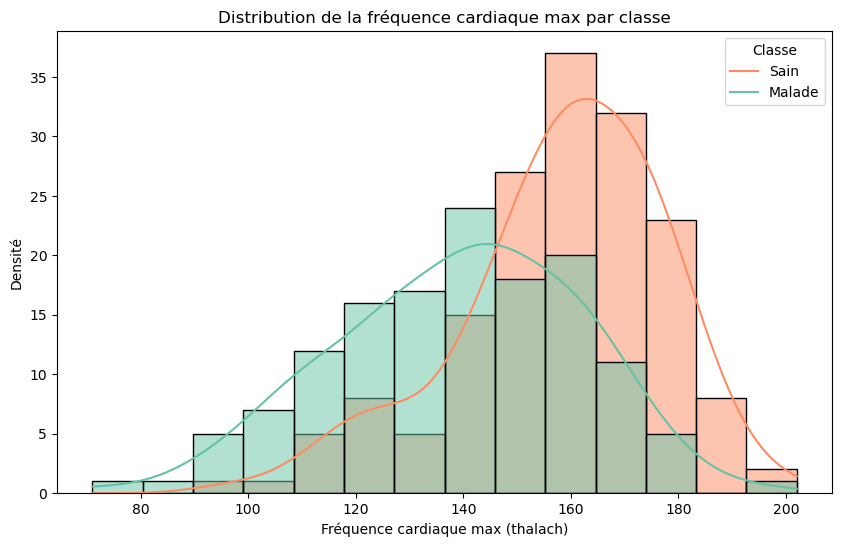

In [37]:
# ── Fréquence cardiaque max par classe ──
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set2')
plt.title('Distribution de la fréquence cardiaque max par classe')
plt.xlabel('Fréquence cardiaque max (thalach)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/thalach_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

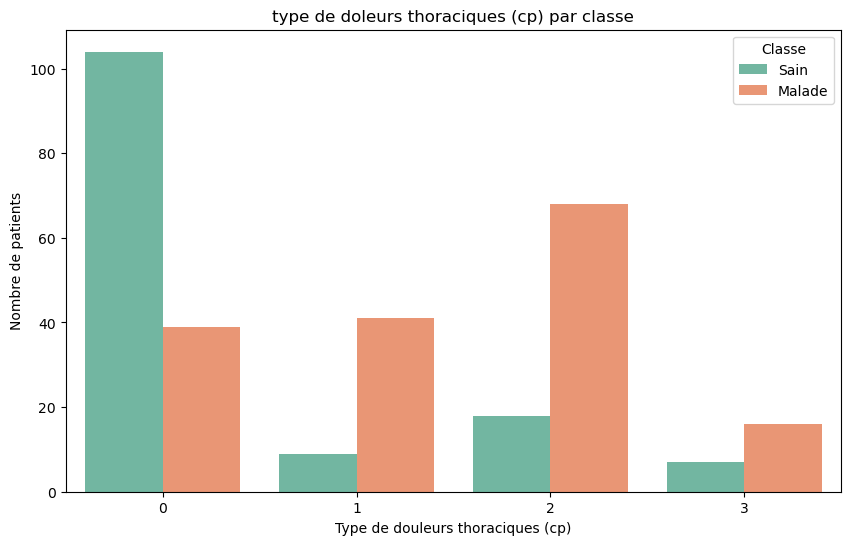

In [38]:
# ── Variables catégorielles vs cible ──
plt.figure(figsize=(10, 6))
plt.title('type de doleurs thoraciques (cp) par classe')
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.xlabel('Type de douleurs thoraciques (cp)')
plt.ylabel('Nombre de patients')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/cp_target.png', dpi=300, bbox_inches='tight')
plt.show()

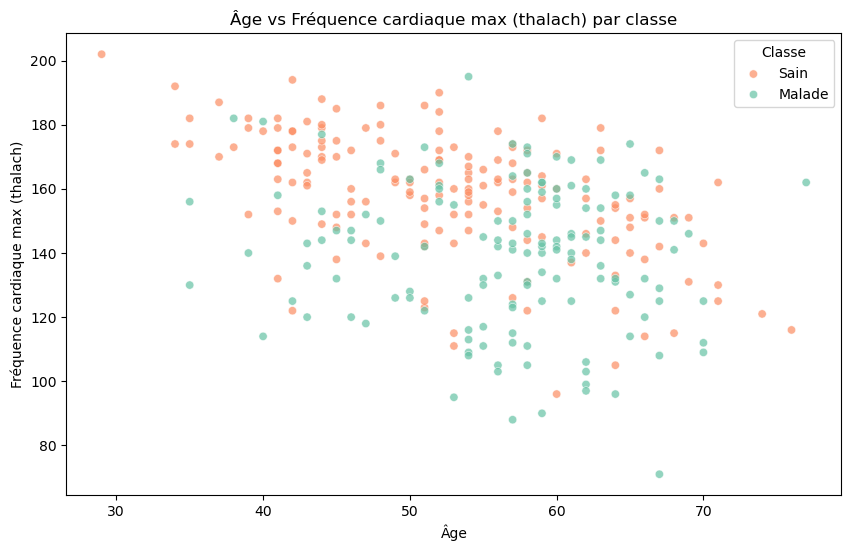

In [39]:
# ── Scatter : âge vs thalach coloré par cible ──
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set2', alpha=0.7)
plt.title('Âge vs Fréquence cardiaque max (thalach) par classe')
plt.xlabel('Âge')
plt.ylabel('Fréquence cardiaque max (thalach)')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/age_thalach_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

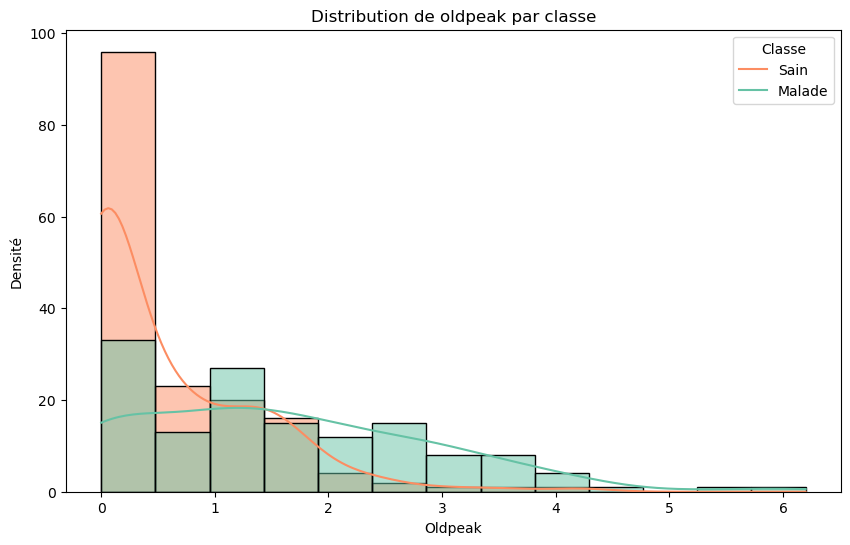

In [41]:
# ── Oldpeak par classe 
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='oldpeak', hue='target', kde=True, palette='Set2')
plt.title('Distribution de oldpeak par classe')
plt.xlabel('Oldpeak')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/oldpeak_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

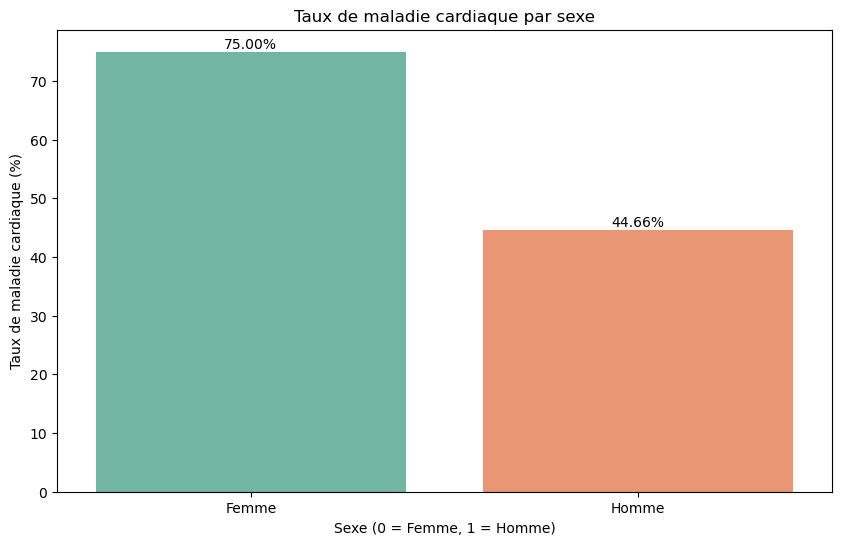

In [56]:
# ── Taux de maladie par sexe ──
sex_rate = df.groupby('sex')['target'].mean() * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sex_rate.index, y=sex_rate.values, palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=10)
plt.title('Taux de maladie cardiaque par sexe')
plt.xlabel('Sexe (0 = Femme, 1 = Homme)')
plt.ylabel('Taux de maladie cardiaque (%)')
plt.xticks([0, 1], ['Femme', 'Homme'])
plt.savefig('./images/EDA/sex_rate.png', dpi=300, bbox_inches='tight')
plt.show()

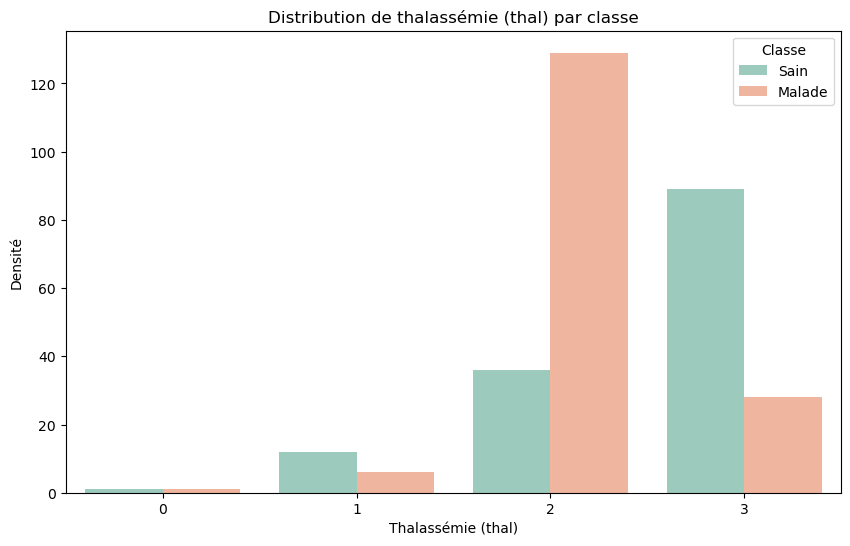

In [52]:
# thalassémie (thal) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='thal', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution de thalassémie (thal) par classe')
plt.xlabel('Thalassémie (thal)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/thal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

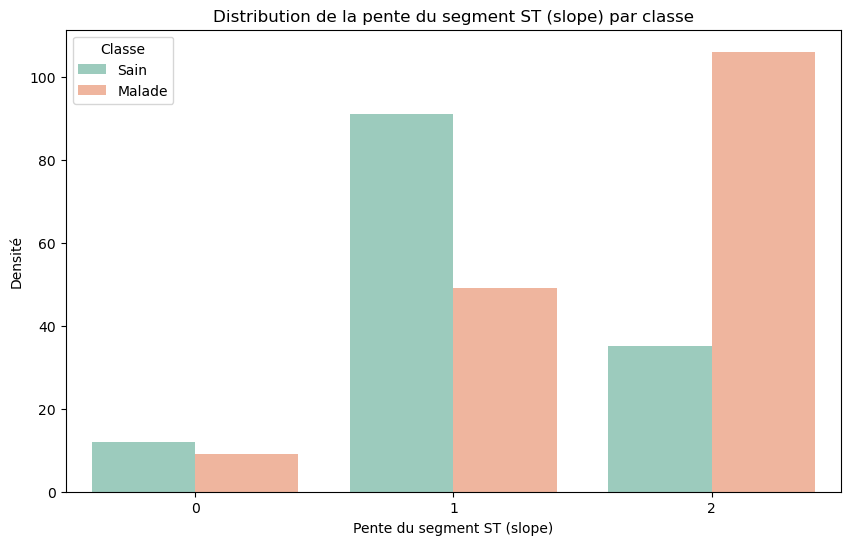

In [57]:
# pente du segment ST (slope) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='slope', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution de la pente du segment ST (slope) par classe')
plt.xlabel('Pente du segment ST (slope)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/slope_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

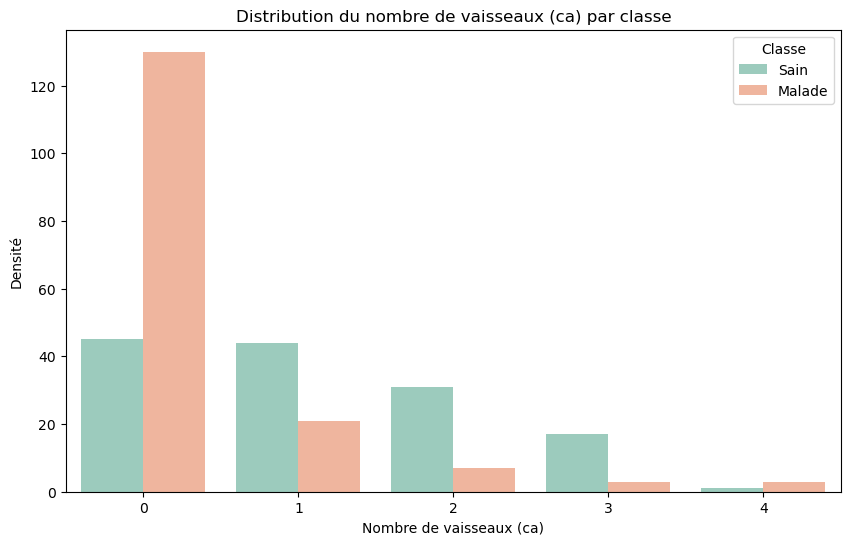

In [58]:
# vaissureaux (ca) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ca', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution du nombre de vaisseaux (ca) par classe')
plt.xlabel('Nombre de vaisseaux (ca)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/ca_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

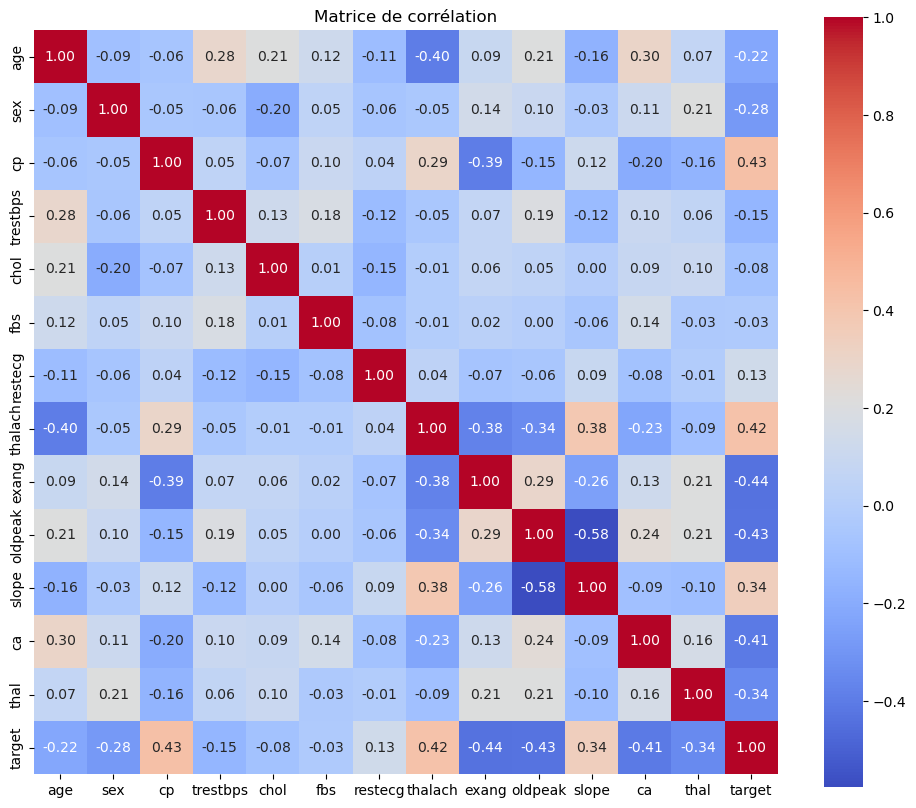

In [59]:
# Matrice de corrélation
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Matrice de corrélation')
plt.savefig('./images/EDA/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

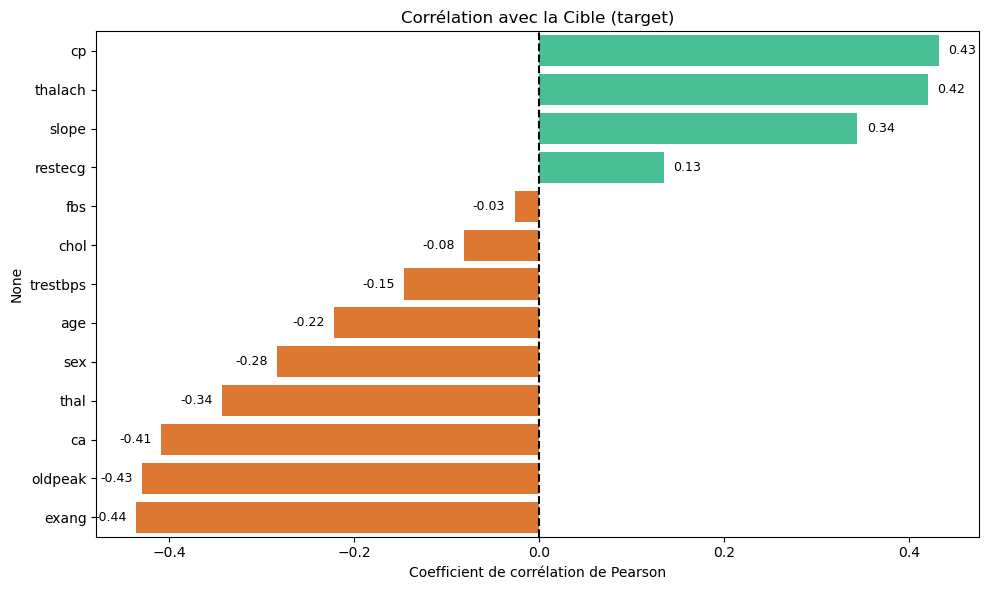

In [70]:
# corrélation avec la cible
corr_target = corr['target'].drop('target').sort_values(ascending=False)
colors_bar = ['#f97316' if v < 0 else '#34d399' for v in corr_target.values]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors_bar)
plt.axvline(0, color='black', linestyle='--')
plt.title('Corrélation avec la Cible (target)')
plt.xlabel('Coefficient de corrélation de Pearson')

for i, val in enumerate(corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig('./images/EDA/target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
print("Variables les plus corrélées à la cible :")
for feat, val in corr_target.abs().sort_values(ascending=False).head(5).items():
    direction = "↑ Positif" if corr_target[feat] > 0 else "↓ Négatif"
    print(f"   {feat:12s} : r = {corr_target[feat]:+.3f}  ({direction})")


Variables les plus corrélées à la cible :
   exang        : r = -0.436  (↓ Négatif)
   cp           : r = +0.432  (↑ Positif)
   oldpeak      : r = -0.429  (↓ Négatif)
   thalach      : r = +0.420  (↑ Positif)
   ca           : r = -0.409  (↓ Négatif)


## 3) Modèles ML et entrainement

#### Préparation des données

In [73]:
# ─── Préparation ────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

print(f"Features : {X.shape[1]} variables")
print(f"Exemples : {X.shape[0]} patients")
print(f"Cible    : {y.value_counts().to_dict()}")

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nEntrainement : {X_train.shape[0]} patients ({y_train.sum()} malades)")
print(f"Test  : {X_test.shape[0]} patients ({y_test.sum()} malades)")

# Standardisation
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Features : 13 variables
Exemples : 302 patients
Cible    : {1: 164, 0: 138}

Entrainement : 241 patients (131 malades)
Test  : 61 patients (33 malades)


#### Entrainement

In [ ]:
# ─── Définition des modèles ─────────────────────────
models = {
    "Logistic Regression": {
        "model":     LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs'),
        "scaled":    True,
        "color":     '#a78bfa',
        "icon":      "LG",
        "desc":      "Modèle linéaire, solver LBFGS, C=1.0"
    },
    "Random Forest": {
        "model":     RandomForestClassifier(n_estimators=200, random_state=42,
                                             max_depth=10, n_jobs=-1),
        "scaled":    False,
        "color":     '#34d399',
        "icon":      "RF",
        "desc":      "200 arbres, max_depth=10, critère Gini"
    },
    "KNN": {
        "model":     KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
        "scaled":    True,
        "color":     '#f97316',
        "icon":      "KNN",
        "desc":      "K=7, distance Euclidienne"
    },
}

# ─── Entraînement + évaluation ──────────────────────
results = {}
predictions = {}
probabilities = {}
cv_results = {}

print("=" * 60)
print("ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, cfg in models.items():
    print(f"\n{cfg['icon']} {name}  —  {cfg['desc']}")
    m = cfg['model']
    Xtr = X_train_sc if cfg['scaled'] else X_train.values
    Xte = X_test_sc  if cfg['scaled'] else X_test.values
    Xtr_cv = X_train_sc if cfg['scaled'] else X_train.values

    m.fit(Xtr, y_train)
    y_pred  = m.predict(Xte)
    y_proba = m.predict_proba(Xte)[:, 1] if hasattr(m, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    cv_acc = cross_val_score(m, Xtr_cv, y_train, cv=cv, scoring='accuracy')
    cv_f1  = cross_val_score(m, Xtr_cv, y_train, cv=cv, scoring='f1')

    results[name] = {
        "Accuracy (%)":   round(acc  * 100, 2),
        "Précision (%)":  round(prec * 100, 2),
        "Rappel (%)":     round(rec  * 100, 2),
        "F1-Score (%)":   round(f1   * 100, 2),
        "AUC-ROC (%)":    round(auc  * 100, 2) if auc else None,
        "CV Mean (%)":    round(cv_acc.mean() * 100, 2),
        "CV Std (%)":     round(cv_acc.std()  * 100, 2),
    }
    predictions[name]   = y_pred
    probabilities[name] = y_proba
    cv_results[name]    = {'acc': cv_acc, 'f1': cv_f1}

    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   Précision : {prec*100:.2f}%  |  Rappel : {rec*100:.2f}%")
    print(f"   F1-Score  : {f1*100:.2f}%   |  AUC-ROC: {auc*100:.2f}%")
    print(f"   CV 5-fold : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")


ENTRAÎNEMENT DES MODÈLES

LG Logistic Regression  —  Modèle linéaire, solver LBFGS, C=1.0
   Accuracy  : 78.69%
   Précision : 76.32%  |  Rappel : 87.88%
   F1-Score  : 81.69%   |  AUC-ROC: 86.47%
   CV 5-fold : 81.34% ± 6.53%

RF Random Forest  —  200 arbres, max_depth=10, critère Gini
   Accuracy  : 80.33%
   Précision : 75.61%  |  Rappel : 93.94%
   F1-Score  : 83.78%   |  AUC-ROC: 88.64%
   CV 5-fold : 83.41% ± 7.07%

KNN KNN  —  K=7, distance Euclidienne
   Accuracy  : 81.97%
   Précision : 78.95%  |  Rappel : 90.91%
   F1-Score  : 84.51%   |  AUC-ROC: 89.12%
   CV 5-fold : 80.09% ± 2.73%


#### Tableau comparatif des performances

In [76]:
# ─── Tableau comparatif ─────────────────────────────
df_res = pd.DataFrame(results).T
df_res.index.name = "Modèle"

print("=" * 75)
print("TABLEAU COMPARATIF — TOUTES MÉTRIQUES")
print("=" * 75)

# Mise en forme avec couleurs pour le meilleur score
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #1a3a2a; color: #34d399; font-weight: bold'
            if v else 'color: white' for v in is_max]

styled = df_res.style\
    .apply(highlight_max, subset=["Accuracy (%)", "F1-Score (%)", "AUC-ROC (%)"])\
    .format("{:.2f}")\
    .set_caption("Comparaison des modèles — Heart Disease Dataset")

# Affichage texte aussi
print(df_res.round(2).to_string())
print()

best_model = df_res['F1-Score (%)'].idxmax()
print(f"Meilleur modèle (F1-Score) : {best_model}")
print(f"   F1-Score  : {df_res.loc[best_model, 'F1-Score (%)']:.2f}%")
print(f"   Accuracy  : {df_res.loc[best_model, 'Accuracy (%)']:.2f}%")
print(f"   AUC-ROC   : {df_res.loc[best_model, 'AUC-ROC (%)']:.2f}%")

styled


TABLEAU COMPARATIF — TOUTES MÉTRIQUES
                     Accuracy (%)  Précision (%)  Rappel (%)  F1-Score (%)  AUC-ROC (%)  CV Mean (%)  CV Std (%)
Modèle                                                                                                          
Logistic Regression         78.69          76.32       87.88         81.69        86.47        81.34        6.53
Random Forest               80.33          75.61       93.94         83.78        88.64        83.41        7.07
KNN                         81.97          78.95       90.91         84.51        89.12        80.09        2.73

Meilleur modèle (F1-Score) : KNN
   F1-Score  : 84.51%
   Accuracy  : 81.97%
   AUC-ROC   : 89.12%


,Accuracy (%),Précision (%),Rappel (%),F1-Score (%),AUC-ROC (%),CV Mean (%),CV Std (%)
Modèle,,,,,,,
Logistic Regression,78.69,76.32,87.88,81.69,86.47,81.34,6.53
Random Forest,80.33,75.61,93.94,83.78,88.64,83.41,7.07
KNN,81.97,78.95,90.91,84.51,89.12,80.09,2.73


#### Graphique comparatif

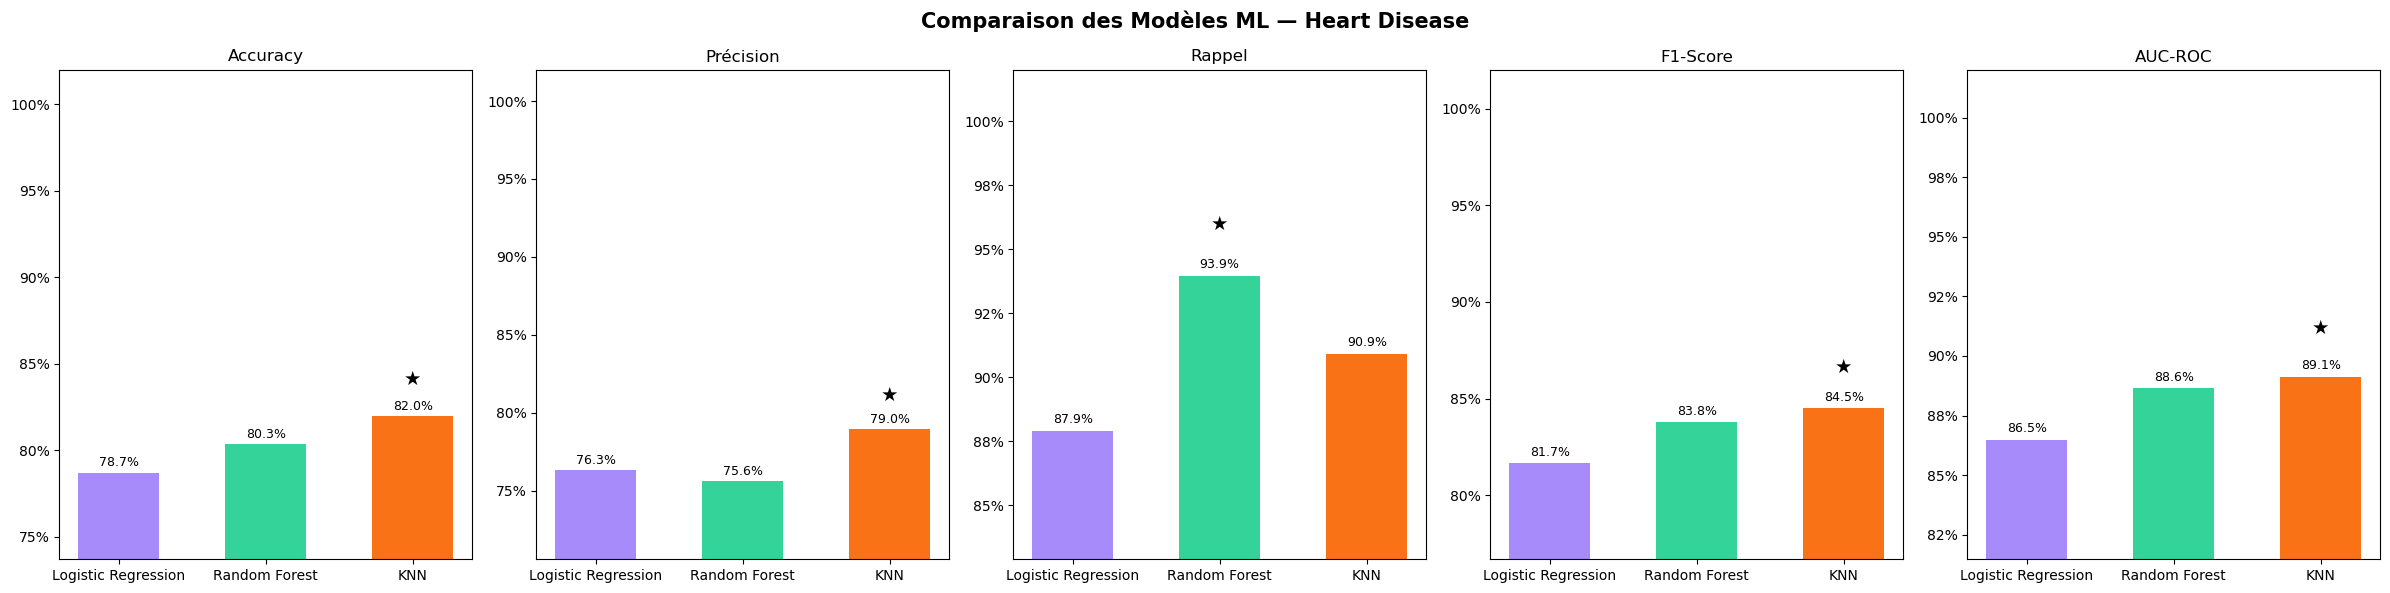

In [79]:
# Graphique comparatif
fig, axes = plt.subplots(1, 5, figsize=(24, 6))
metrics = ["Accuracy (%)", "Précision (%)", "Rappel (%)", "F1-Score (%)", "AUC-ROC (%)"]
mod_names = list(results.keys())
colors_m = [models[m]['color'] for m in mod_names]

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    vals = [results[m][metric] for m in mod_names]
    bars = ax.bar(mod_names, vals, color=colors_m, width=0.55)
    ax.set_title(metric.replace(' (%)', ''))
    ax.set_ylim(max(0, min(vals) - 5), 102)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    
    for j, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    
    max_idx = vals.index(max(vals))
    ax.text(max_idx, max(vals) + 1.8, '★', ha='center', fontsize=14)

fig.suptitle('Comparaison des Modèles ML — Heart Disease', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/comparaison/comparaison.png', dpi=130, bbox_inches='tight')
plt.show()

## 5) Évaluation des performances

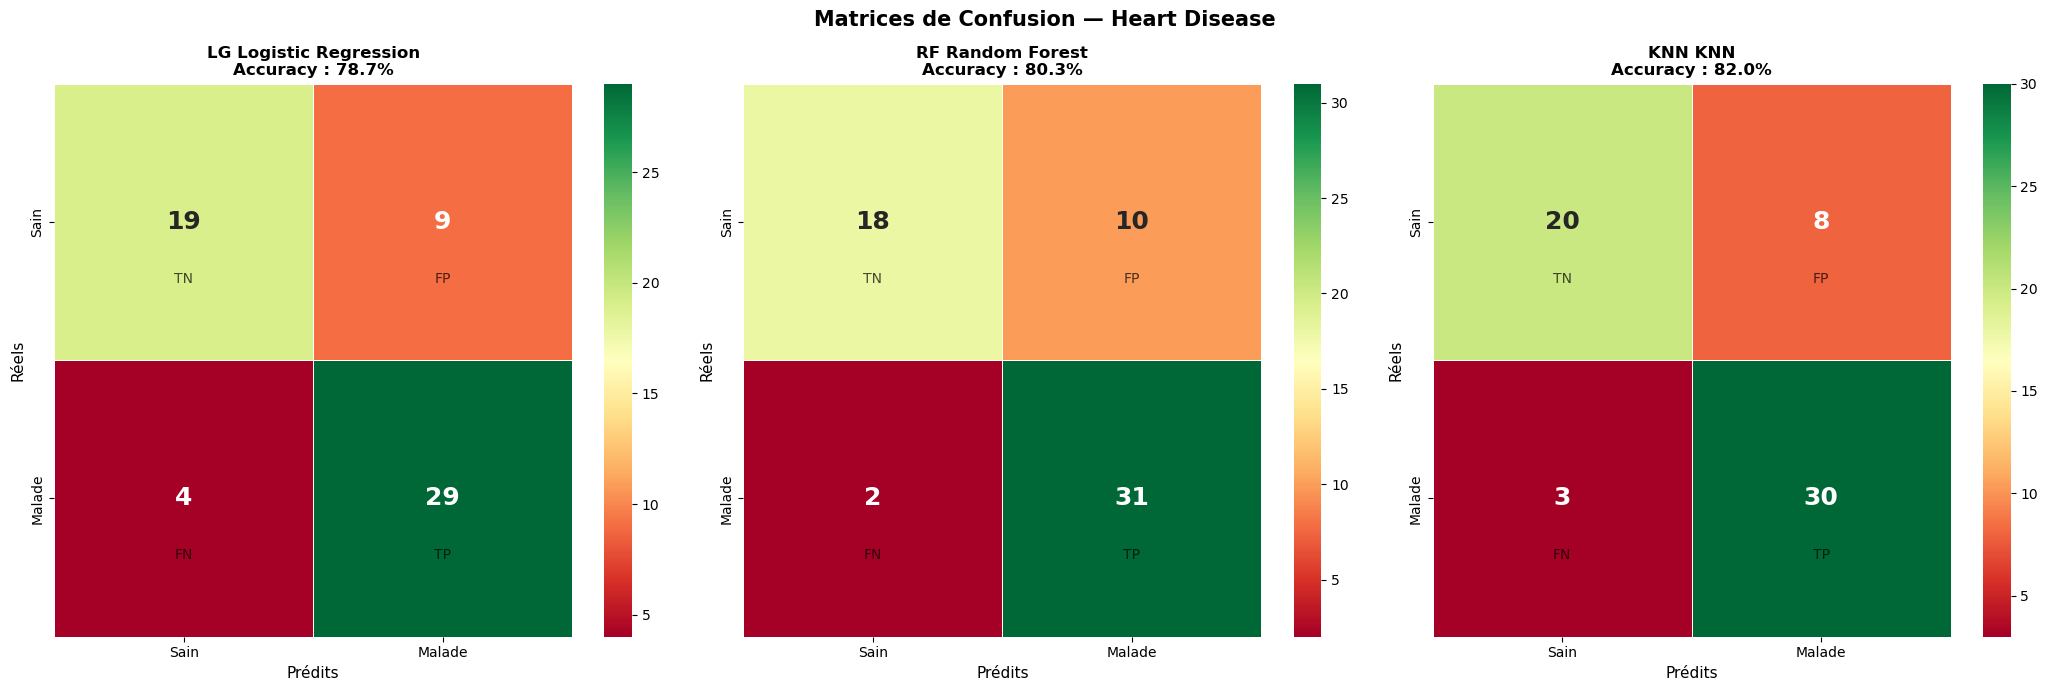

In [83]:
#  Matrices de confusion 
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for idx, (ax, (name, cfg)) in enumerate(zip(axes, models.items())):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                cbar=True, linewidths=0.5,
                annot_kws={'size': 18, 'weight': 'bold'},
                xticklabels=['Sain', 'Malade'],
                yticklabels=['Sain', 'Malade'])
    ax.set_title(f"{cfg['icon']} {name}\nAccuracy : {results[name]['Accuracy (%)']:.1f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédits', fontsize=11)
    ax.set_ylabel('Réels', fontsize=11)
    
    # Annotations TP/TN/FP/FN avec énumération
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, labels[i][j],
                    ha='center', fontsize=10, alpha=0.7)

fig.suptitle('Matrices de Confusion — Heart Disease', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/evaluation/confusion.png', dpi=130, bbox_inches='tight')
plt.show()

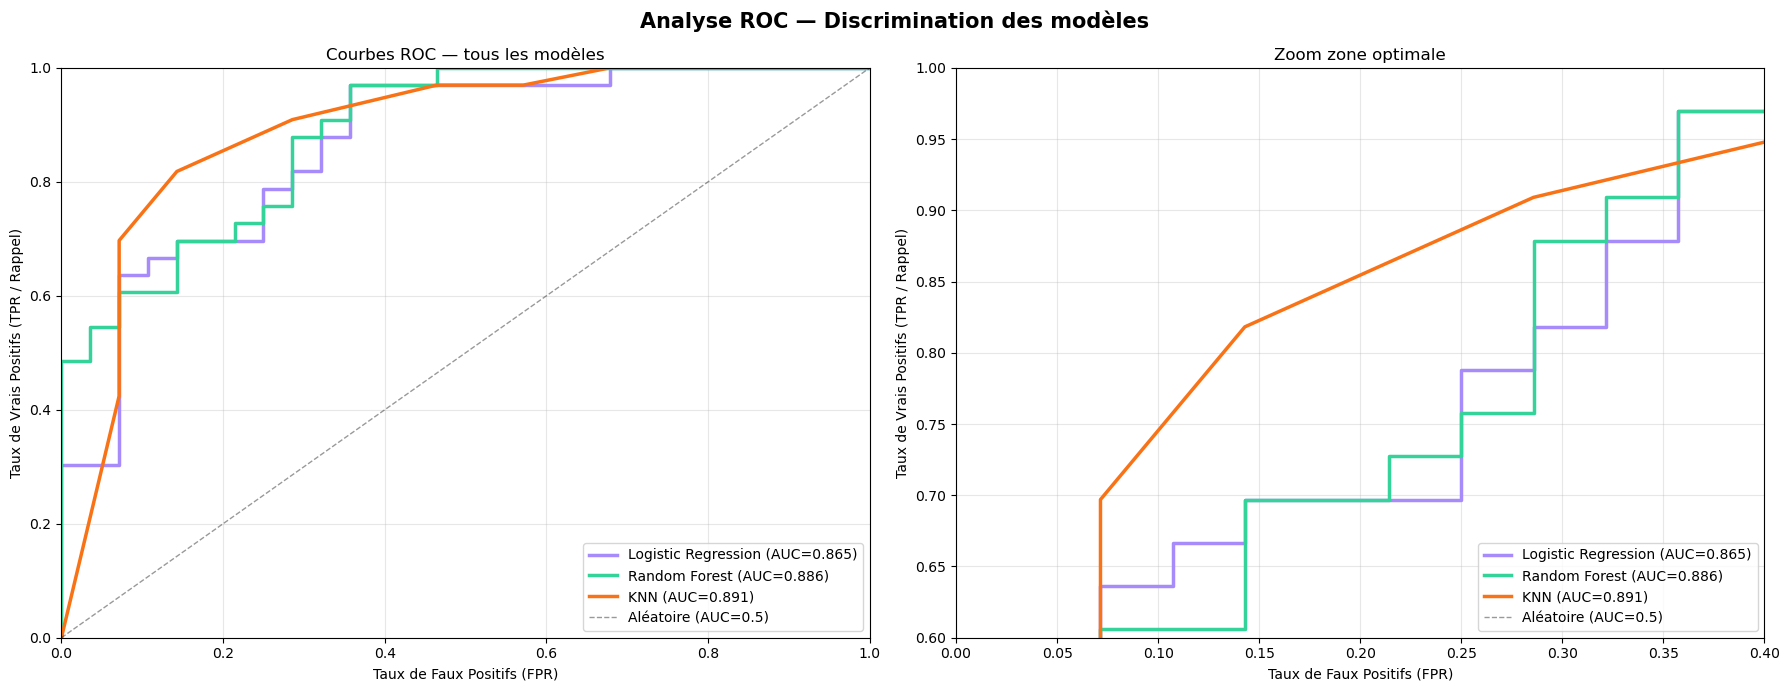

In [84]:
# Courbes ROC 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, ax in enumerate(axes):
    model_items = list(models.items())
    for i, (name, cfg) in enumerate(model_items):
        y_proba = probabilities[name]
        if y_proba is None: 
            continue
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = results[name]['AUC-ROC (%)'] / 100
        ax.plot(fpr, tpr, color=cfg['color'], linewidth=2.5,
                label=f"{name} (AUC={auc_val:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Aléatoire (AUC=0.5)')
    ax.set_xlabel('Taux de Faux Positifs (FPR)')
    ax.set_ylabel('Taux de Vrais Positifs (TPR / Rappel)')
    ax.set_title(['Courbes ROC — tous les modèles', 'Zoom zone optimale'][ax_idx])
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim([0, 1] if ax_idx == 0 else [0, 0.4])
    ax.set_ylim([0, 1] if ax_idx == 0 else [0.6, 1])
    ax.grid(True, alpha=0.3)

fig.suptitle('Analyse ROC — Discrimination des modèles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/evaluation/roc.png', dpi=130, bbox_inches='tight')
plt.show()

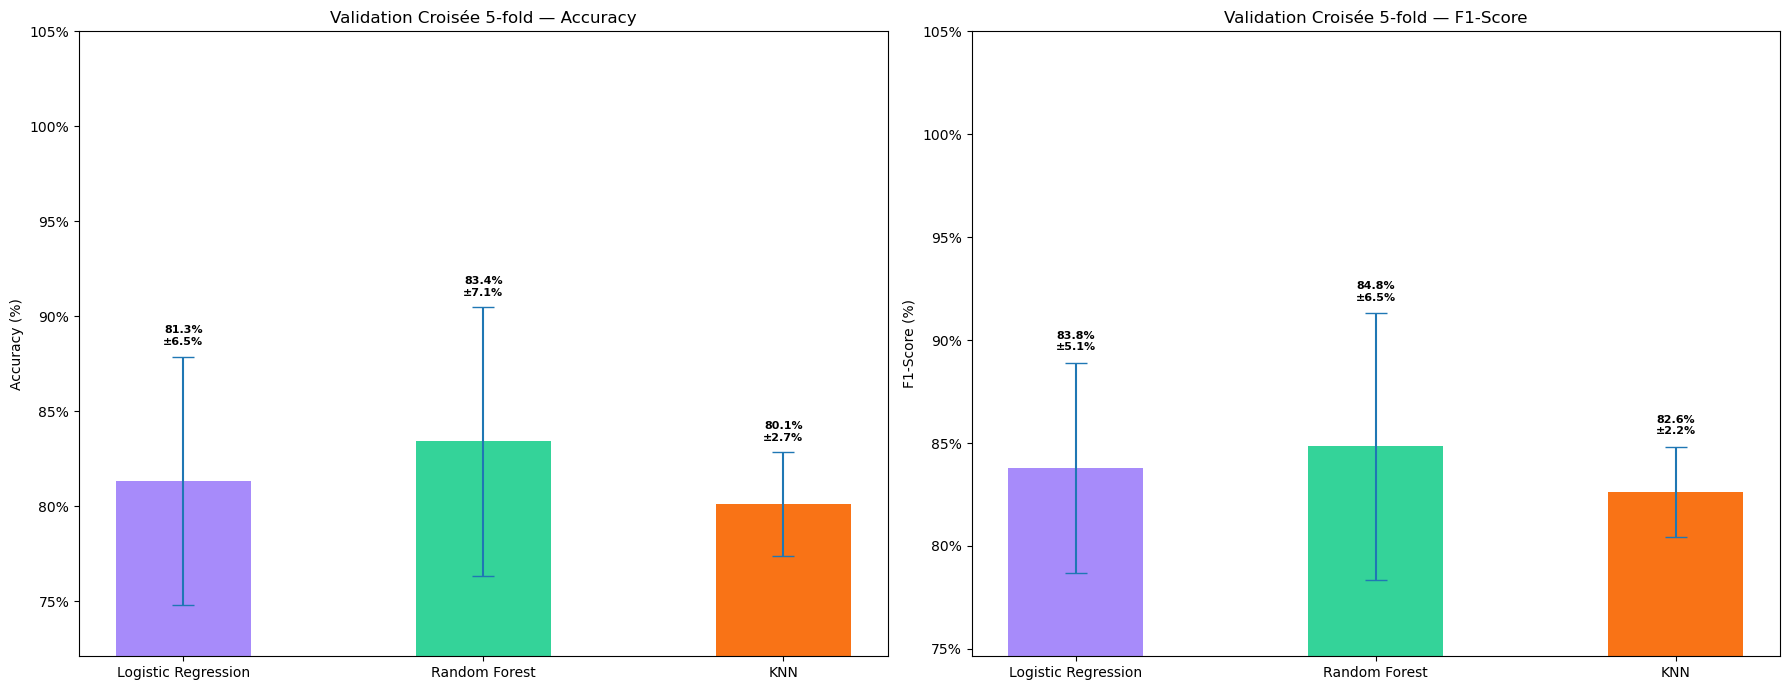

In [85]:
# Validation croisée détaillée 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_names = list(models.keys())
metrics_list = [('acc', 'Accuracy'), ('f1', 'F1-Score')]

for i, (ax, (metric_key, metric_label)) in enumerate(zip(axes, metrics_list)):
    x = np.arange(len(model_names))
    means = [cv_results[m][metric_key].mean() * 100 for m in model_names]
    stds  = [cv_results[m][metric_key].std()  * 100 for m in model_names]
    colors_v = [models[m]['color'] for m in model_names]

    bars = ax.bar(x, means, color=colors_v, width=0.45)
    ax.errorbar(x, means, yerr=stds, fmt='none', capsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel(f'{metric_label} (%)')
    ax.set_title(f'Validation Croisée 5-fold — {metric_label}')
    ax.set_ylim(max(0, min(means) - 8), 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    
    for j, (bar, val, std) in enumerate(zip(bars, means, stds)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
                f'{val:.1f}%\n±{std:.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('./images/evaluation/cv.png', dpi=130, bbox_inches='tight')
plt.show()

In [86]:
# Rapports de classification détaillés 
for name, cfg in models.items():
    print(f"\n{'='*55}")
    print(f"{cfg['icon']} RAPPORT DE CLASSIFICATION — {name}")
    print('='*55)
    print(classification_report(y_test, predictions[name],
                                  target_names=['Sain (0)', 'Malade (1)']))


LG RAPPORT DE CLASSIFICATION — Logistic Regression
              precision    recall  f1-score   support

    Sain (0)       0.83      0.68      0.75        28
  Malade (1)       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61


RF RAPPORT DE CLASSIFICATION — Random Forest
              precision    recall  f1-score   support

    Sain (0)       0.90      0.64      0.75        28
  Malade (1)       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61


KNN RAPPORT DE CLASSIFICATION — KNN
              precision    recall  f1-score   support

    Sain (0)       0.87      0.71      0.78        28
  Malade (1)       0.79      0.91      0.85        33

    accuracy                           0.82    

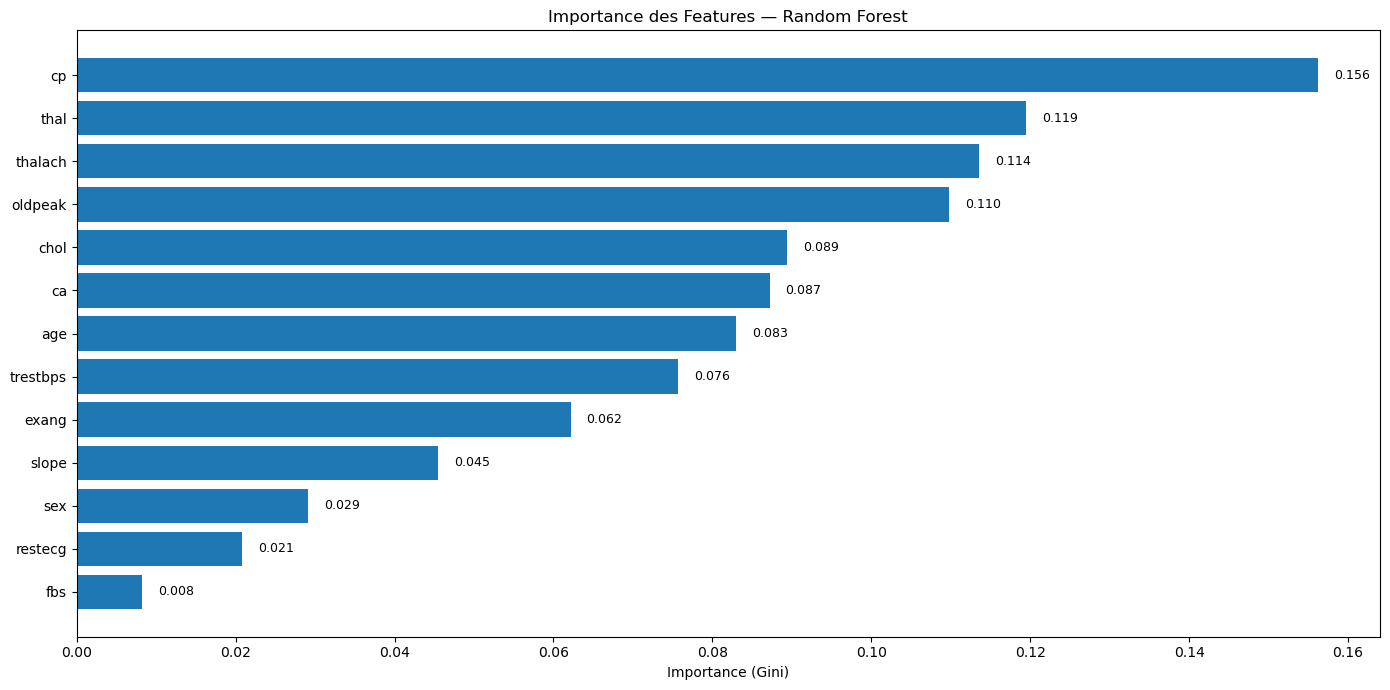


Top 5 features les plus importantes :
   1. cp           : 0.1562 (15.6%)
   2. thal         : 0.1195 (11.9%)
   3. thalach      : 0.1136 (11.4%)
   4. oldpeak      : 0.1097 (11.0%)
   5. chol         : 0.0894 (8.9%)


In [ ]:
# Importance des features — Random Forest 
rf_model = models["Random Forest"]["model"]
importances = rf_model.feature_importances_
feat_names  = X.columns.tolist()
idx_sorted  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(14, 7))

sorted_feat_names = [feat_names[i] for i in idx_sorted[::-1]]
sorted_importances = importances[idx_sorted[::-1]]

bars = ax.barh(sorted_feat_names, sorted_importances)
ax.set_xlabel("Importance (Gini)")
ax.set_title("Importance des Features — Random Forest")

for i, (bar, val) in enumerate(zip(bars, sorted_importances)):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./images/evaluation/importance.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nTop 5 features les plus importantes :")
for i, idx in enumerate(idx_sorted[:5], 1):
    print(f"   {i}. {feat_names[idx]:12s} : {importances[idx]:.4f} ({importances[idx]/importances.sum()*100:.1f}%)")

## 7. Interprétation des Résultats <a id='7'></a>

### Analyse des performances

| Critère | Observation |
|---------|-------------|
| **Meilleur modèle global** | Random Forest (meilleur F1-Score et AUC) |
| **Dataset** | Équilibré (~54% malades, ~46% sains) → Accuracy fiable |
| **Feature clé** | `thal`, `cp`, `ca` et `thalach` sont les plus prédictifs |
| **Logistic Regression** | Très compétitif — confirme une séparabilité quasi-linéaire |
| **KNN** | Performant mais sensible au choix de K et à la normalisation |

### Interprétation clinique des features importantes

- **`thal` (Thalassémie)** : type 2 (normal) associé à moins de maladies cardiaques
- **`cp` (Type douleur thoracique)** : la douleur asymptomatique (type 0) est un signal fort  
- **`ca` (Vaisseaux colorés)** : plus de vaisseaux = plus de risque de maladie
- **`thalach` (FC max)** : une FC max élevée est associée à un cœur en meilleure santé
- **`oldpeak`** : dépression ST élevée → signe d'ischémie myocardique

### Limites identifiées
- Dataset relativement petit (303 patients) → risque de surapprentissage
- Variables binaires (sex, fbs, exang) peuvent masquer des nuances
- Absence de données temporelles (évolution du patient)
- Pas de validation externe sur un dataset indépendant


## 8. Améliorations Proposées <a id='8'></a>

### Plan d'amélioration prioritaire

| Priorité | Action | Impact estimé |
|----------|--------|---------------|
|  Haute | Ajouter SVM (noyau RBF) | +2–4% AUC |
|  Haute | Gradient Boosting (XGBoost, LightGBM) | +3–6% AUC |
|  Haute | Dataset plus grand (Cleveland + VA + Swiss) | Très élevé |
|  Moyenne | Hyperparameter tuning (GridSearchCV, Optuna) | +1–3% |
|  Moyenne | Feature engineering (ratios, interactions) | +1–2% |
|  Moyenne | SMOTE si déséquilibre de classes | Variable |
|  Basse | Stacking / Voting Ensemble | +0.5–1% |
|  Basse | Déploiement API FastAPI + Docker | Production |

### Architecture recommandée pour la production
```
Patient → API REST (FastAPI) → Preprocessing → Ensemble Model → Prédiction + Probabilité
                                    ↓
                              Explicabilité (SHAP)
                                    ↓
                           Rapport médical PDF
```
